# Performance and Accuracy Summary

This notebook loads the evaluation metrics JSON, summarizes the per-video performance with histograms, and visualizes the accuracy counts as a confusion matrix.

In [1]:
from pathlib import Path
import json
import math
import statistics

import matplotlib.pyplot as plt

candidate_paths = [
    Path("data/combined_eval_videos_old/performance_metrics.json"),
    Path("../data/combined_eval_videos_old/performance_metrics.json"),
]
metrics_path = next(path for path in candidate_paths if path.exists())

with metrics_path.open("r", encoding="utf-8") as handle:
    raw_metrics = json.load(handle)

video_metrics = {name: values for name, values in raw_metrics.items() if name.startswith("video_")}
accuracy_metrics = raw_metrics["accuracy_metrics"]

print(f"Loaded {len(video_metrics)} video summaries from {metrics_path}")


Loaded 46 video summaries from ../data/combined_eval_videos_old/performance_metrics.json


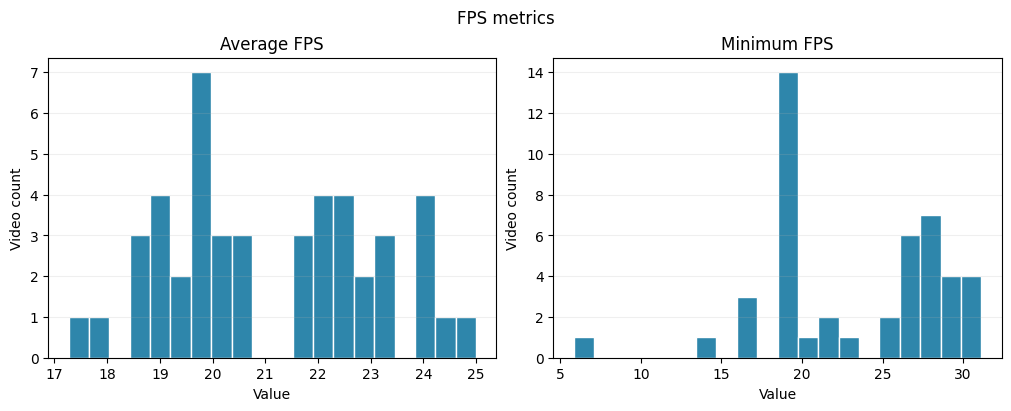

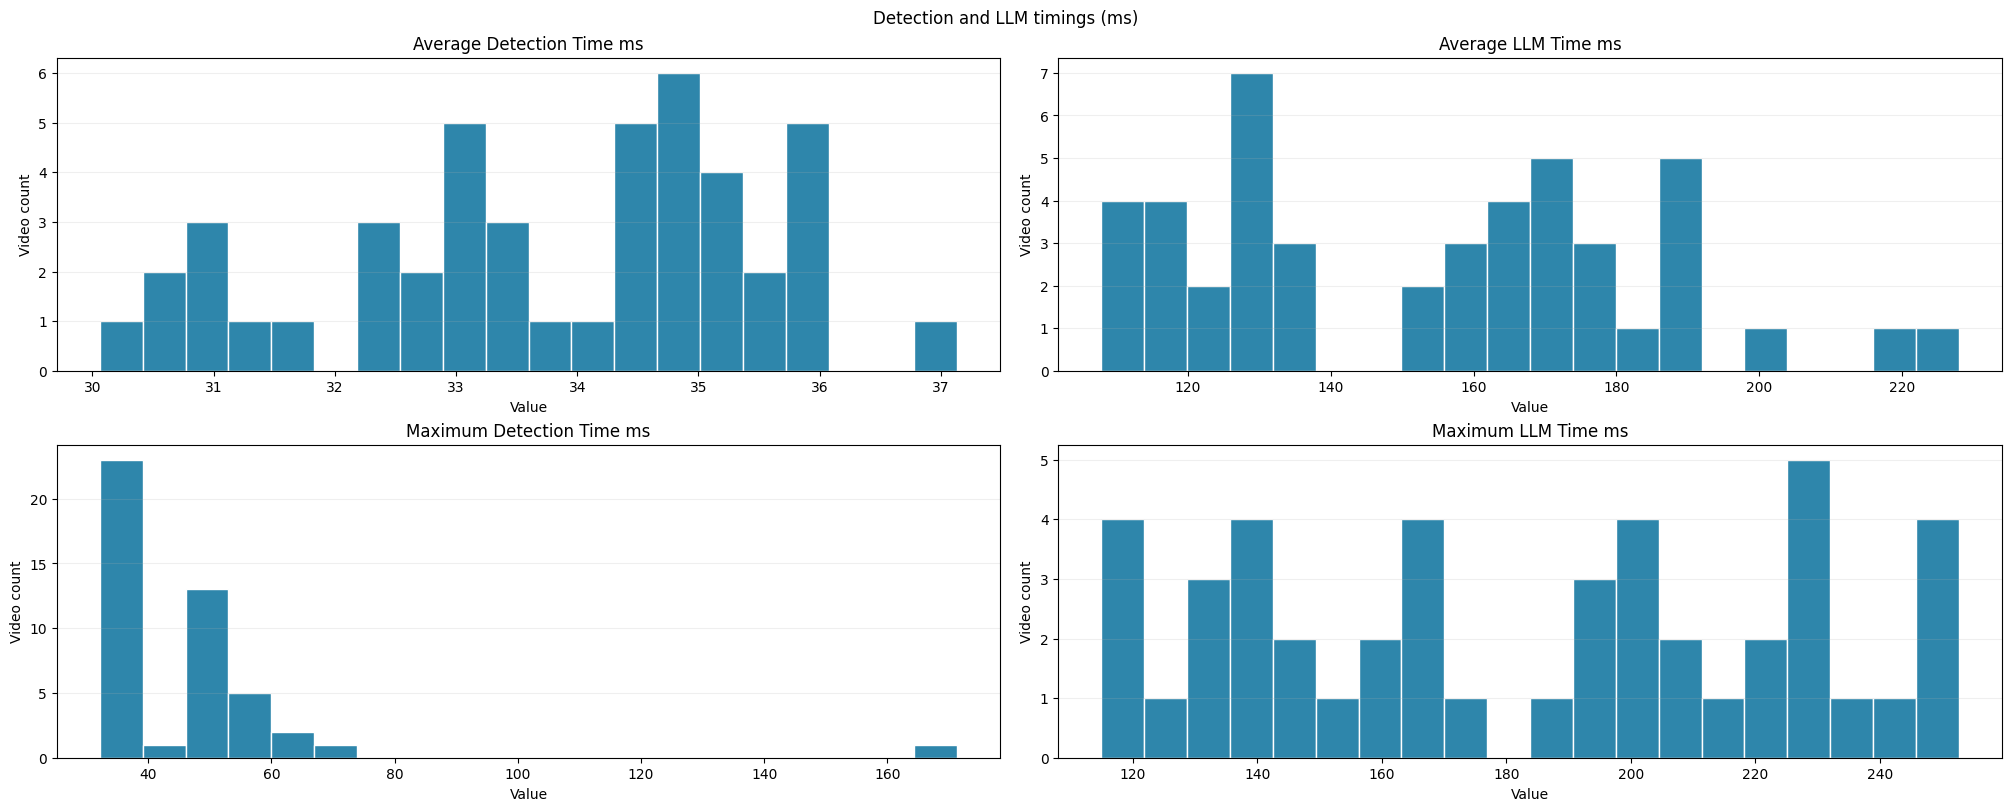

Per-metric summary:
avg_fps: min=17.27, max=25.00, mean=21.11, median=20.41
min_fps: min=5.84, max=31.13, mean=23.29, median=24.09
avg_detection_time_ms: min=30.06, max=37.14, mean=33.73, median=34.26
avg_llm_time_ms: min=107.88, max=227.93, mean=153.14, median=159.12
max_detection_time_ms: min=32.13, max=171.35, mean=46.99, median=41.69
max_llm_time_ms: min=114.96, max=252.69, mean=183.16, median=189.84


In [2]:
metric_groups = [
    ("FPS metrics", ["avg_fps", "min_fps"], 20),
    ("Detection and LLM timings (ms)", ["avg_detection_time_ms", "avg_llm_time_ms", "max_detection_time_ms", "max_llm_time_ms"], 20),
]

for title, keys, bins in metric_groups:
    if len(keys) > 2:
        fig, axes = plt.subplots(2, len(keys) // 2, figsize=(
            5 * len(keys), 8), constrained_layout=True)
        axes = axes.flatten()

    else:
        fig, axes = plt.subplots(1, len(keys), figsize=(5 * len(keys), 4), constrained_layout=True)
    if len(keys) == 1:
        axes = [axes]

    for axis, key in zip(axes, keys):
        values = [metrics[key] for metrics in video_metrics.values()]
        axis.hist(values, bins=bins, color="#2E86AB", edgecolor="white")
        axis.set_title(
            key.replace("_", " ")
            .title()
            .replace("Ms", "ms")
            .replace("Fps", "FPS")
            .replace("Avg", "Average")
            .replace("Min", "Minimum")
            .replace("Max", "Maximum")
            .replace("Llm", "LLM")
        )
        axis.set_xlabel("Value")
        axis.set_ylabel("Video count")
        axis.grid(axis="y", alpha=0.2)

    fig.suptitle(title)
    plt.savefig(f"{title.replace(' ', '_').lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

print("Per-metric summary:")
for key in ["avg_fps", "min_fps", "avg_detection_time_ms", "avg_llm_time_ms", "max_detection_time_ms", "max_llm_time_ms"]:
    values = [metrics[key] for metrics in video_metrics.values()]
    print(
        f"{key}: min={min(values):.2f}, max={max(values):.2f}, mean={statistics.mean(values):.2f}, median={statistics.median(values):.2f}"
    )

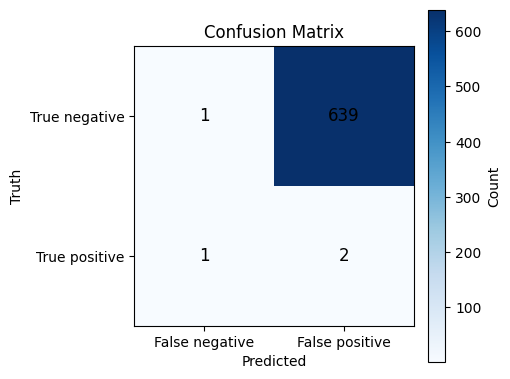

Accuracy metrics:
precision: 0.003120
recall: 0.666667
jaccard: 0.003115
TP=2, TN=1, FP=639, FN=1


In [ ]:
confusion_matrix = [
    [accuracy_metrics["TN"], accuracy_metrics["FP"]],
    [accuracy_metrics["FN"], accuracy_metrics["TP"]],
]

fig, axis = plt.subplots(figsize=(5, 4), constrained_layout=True)
image = axis.imshow(confusion_matrix, cmap="Blues")
axis.set_xticks([0, 1], labels=["Predicted negative", "Predicted positive"])
axis.set_yticks([0, 1], labels=["Actual negative", "Actual positive"])
axis.set_title("Confusion Matrix")

for row_index in range(2):
    for col_index in range(2):
        axis.text(col_index, row_index, confusion_matrix[row_index][col_index], ha="center", va="center", color="black", fontsize=12)

axis.set_xlabel("Prediction")
axis.set_ylabel("Truth")
fig.colorbar(image, ax=axis, shrink=0.9, label="Count")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy metrics:")
for key in ["precision", "recall", "jaccard"]:
    print(f"{key}: {accuracy_metrics[key]:.6f}")
print(f"TP={accuracy_metrics['TP']}, TN={accuracy_metrics['TN']}, FP={accuracy_metrics['FP']}, FN={accuracy_metrics['FN']}")